# 🤖 Notebook 02 — Training & Evaluasi Model ML
## GPS Tracker Bus Sekolah — ETA Prediction

### ✅ Checklist yang dicakup notebook ini:
- [x] 1. EDA & Feature Engineering
- [x] 2. Preprocessing + Pipeline sklearn
- [x] 3. Split dataset (train/val/test)
- [x] 4. Build minimal 2 model (XGBoost + LightGBM)
- [x] 5. Hyperparameter Tuning (Optuna)
- [x] 6. Cross-validation
- [x] 7. Evaluasi: MAE, RMSE, R²
- [x] 8. Feature Importance
- [x] 9. Simpan model (.pkl)
- [x] 10. Inference sederhana

## 0️⃣ Mount Google Drive & Set Base Path

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# Sesuaikan dengan lokasi folder ml-eta di Google Drive kamu
BASE_PATH = '/content/drive/MyDrive/ml-eta'

import os
os.makedirs(f'{BASE_PATH}/data', exist_ok=True)
os.makedirs(f'{BASE_PATH}/models', exist_ok=True)

print(f'Drive terhubung! BASE_PATH = {BASE_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive terhubung! BASE_PATH = /content/drive/MyDrive/ml-eta


## 1️⃣ Import & Konfigurasi

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge

# Models
import xgboost as xgb
import lightgbm as lgb

# Hyperparameter Tuning
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Logging
!pip install mlflow
import mlflow
import mlflow.sklearn

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print('✅ Semua library berhasil dimuat!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

## 2️⃣ Load Data Bersih (dari Notebook 01)

In [7]:
df = pd.read_csv(f'{BASE_PATH}/data/data_clean.csv')
print(f'Shape: {df.shape}')
print(f'Target (duration_min) — min: {df["duration_min"].min():.1f}, max: {df["duration_min"].max():.1f}, mean: {df["duration_min"].mean():.1f}')
df.head()

Shape: (47304, 14)
Target (duration_min) — min: 2.0, max: 119.8, mean: 11.7


,start_lat,start_lon,end_lat,end_lon,straight_dist_km,distance_km,hour,day_of_week,month,is_weekend,is_rush_hour,time_category,CALL_TYPE,duration_min
0,41.141412,-8.618643,41.154489,-8.630838,1.776808,2.651048,0,0,7,0,0,malam,C,5.5
1,41.159826,-8.639847,41.170671,-8.665740,2.480360,3.456269,0,0,7,0,0,malam,B,4.5
2,41.140359,-8.612964,41.140530,-8.615970,0.252442,17.630449,0,0,7,0,0,malam,C,16.0
3,41.151951,-8.574678,41.142915,-8.607996,2.965199,7.968045,0,0,7,0,0,malam,C,10.5
4,41.180490,-8.645994,41.178087,-8.687268,3.464589,4.814326,0,0,7,0,0,malam,C,7.0


## 3️⃣ Feature Engineering Tambahan

In [8]:
# Rasio jarak lurus vs jarak aktual (semakin kecil = rute lebih berliku)
df['detour_ratio'] = df['distance_km'] / (df['straight_dist_km'] + 1e-9)

# Sin & Cos encoding untuk fitur siklis (jam)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7)

print('✅ Feature engineering selesai!')
print(f'Total fitur: {df.shape[1]}')

✅ Feature engineering selesai!
Total fitur: 19


## 4️⃣ Definisi Fitur & Target

In [9]:
TARGET = 'duration_min'

NUMERIC_FEATURES = [
    'start_lat', 'start_lon', 'end_lat', 'end_lon',
    'straight_dist_km', 'distance_km', 'detour_ratio',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'is_rush_hour', 'month'
]

CATEGORICAL_FEATURES = ['time_category', 'CALL_TYPE']

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df[ALL_FEATURES]
y = df[TARGET]

print(f'Fitur numerik  : {len(NUMERIC_FEATURES)}')
print(f'Fitur kategori : {len(CATEGORICAL_FEATURES)}')
print(f'Total fitur    : {len(ALL_FEATURES)}')
print(f'Total data     : {len(X):,}')

Fitur numerik  : 14
Fitur kategori : 2
Total fitur    : 16
Total data     : 47,304


## 5️⃣ Split Dataset — Train / Validation / Test

In [10]:
# Split 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Split 80% train, 20% val (dari X_temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

print(f'Train  : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val    : {len(X_val):,}   ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test   : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')

Train  : 30,274 (64.0%)
Val    : 7,569   (16.0%)
Test   : 9,461  (20.0%)


## 6️⃣ Preprocessing Pipeline (sklearn.Pipeline)

In [11]:
# Preprocessor untuk numerik
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessor untuk kategorik
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer gabungan
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

print('✅ Preprocessor pipeline siap!')

✅ Preprocessor pipeline siap!


## 7️⃣ Model 1 — Ridge Regression (Baseline)

In [12]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'📊 [{name}]')
    print(f'   MAE  : {mae:.4f} menit')
    print(f'   RMSE : {rmse:.4f} menit')
    print(f'   R²   : {r2:.4f}')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []

# Pipeline Ridge
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge_val = ridge_pipeline.predict(X_val)

results.append(evaluate('Ridge Baseline (Val)', y_val, y_pred_ridge_val))

📊 [Ridge Baseline (Val)]
   MAE  : 3.4245 menit
   RMSE : 5.7810 menit
   R²   : 0.4722


## 8️⃣ Model 2 — XGBoost

In [13]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb_val = xgb_pipeline.predict(X_val)

results.append(evaluate('XGBoost (Val)', y_val, y_pred_xgb_val))

📊 [XGBoost (Val)]
   MAE  : 2.7530 menit
   RMSE : 5.1569 menit
   R²   : 0.5800


## 9️⃣ Model 3 — LightGBM

In [14]:
lgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

lgb_pipeline.fit(X_train, y_train)
y_pred_lgb_val = lgb_pipeline.predict(X_val)

results.append(evaluate('LightGBM (Val)', y_val, y_pred_lgb_val))

📊 [LightGBM (Val)]
   MAE  : 2.7676 menit
   RMSE : 5.1891 menit
   R²   : 0.5748


## 🔟 Hyperparameter Tuning — Optuna (LightGBM)

In [15]:
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', lgb.LGBMRegressor(**params))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    return mean_absolute_error(y_val, y_pred)

print('🔍 Mulai Optuna tuning (50 trial)...')
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\n✅ Best MAE: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

🔍 Mulai Optuna tuning (50 trial)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best MAE: 2.7051
Best params: {'n_estimators': 391, 'learning_rate': 0.04897714971850069, 'max_depth': 10, 'num_leaves': 101, 'subsample': 0.6539635273021567, 'colsample_bytree': 0.9783319193208185, 'reg_alpha': 1.3523218935805656e-06, 'reg_lambda': 1.3514517822228374}


## 1️⃣1️⃣ Model Terbaik dengan Params Optimal

In [16]:
best_params = study.best_params
best_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMRegressor(**best_params))
])

# Train dengan data train + val
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
best_pipeline.fit(X_trainval, y_trainval)

# Evaluasi final di TEST set
y_pred_test = best_pipeline.predict(X_test)
final_result = evaluate('LightGBM Tuned (TEST)', y_test, y_pred_test)
results.append(final_result)

📊 [LightGBM Tuned (TEST)]
   MAE  : 2.6949 menit
   RMSE : 5.1774 menit
   R²   : 0.5748


## 1️⃣2️⃣ Cross-Validation

In [17]:
print('🔄 Menjalankan 5-Fold Cross-Validation...')

cv_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMRegressor(**best_params))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_mae  = -cross_val_score(cv_pipeline, X, y, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_rmse = np.sqrt(-cross_val_score(cv_pipeline, X, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1))

print(f'\n📊 Cross-Validation Results (5-Fold):')
print(f'   MAE  : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')
print(f'   RMSE : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}')

🔄 Menjalankan 5-Fold Cross-Validation...

📊 Cross-Validation Results (5-Fold):
   MAE  : 2.6437 ± 0.0719
   RMSE : 5.0032 ± 0.1911


## 1️⃣3️⃣ Perbandingan Semua Model

                model      MAE     RMSE       R2
 Ridge Baseline (Val) 3.424486 5.781019 0.472229
        XGBoost (Val) 2.752970 5.156877 0.580038
       LightGBM (Val) 2.767639 5.189107 0.574772
LightGBM Tuned (TEST) 2.694878 5.177400 0.574825


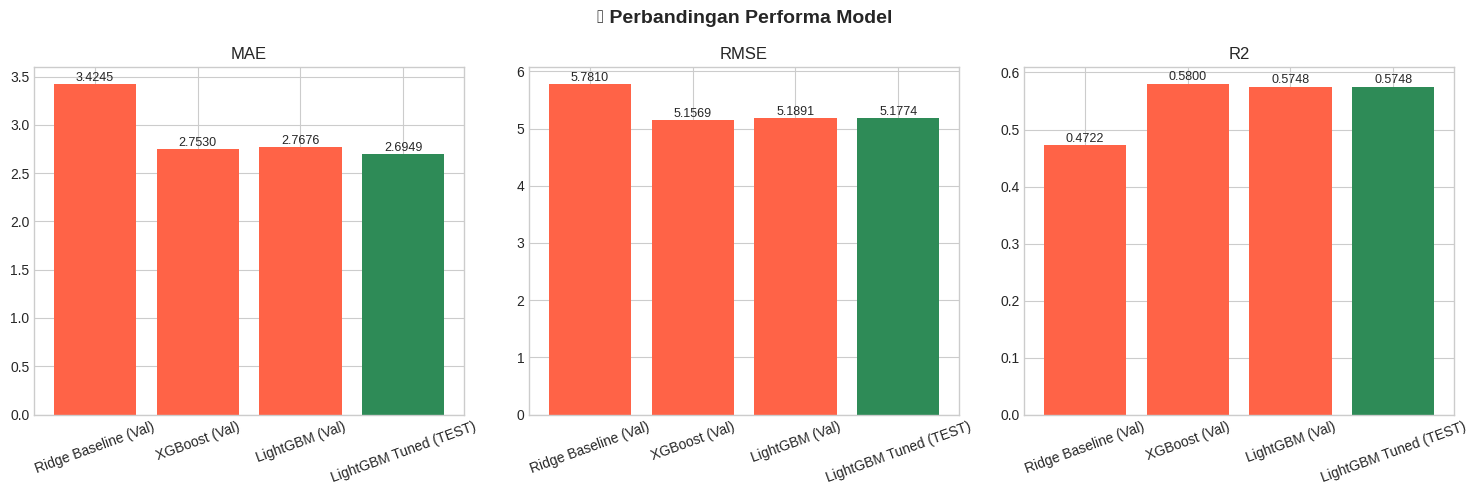

In [18]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('📊 Perbandingan Performa Model', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    colors = ['tomato' if i < len(results_df)-1 else 'seagreen' for i in range(len(results_df))]
    bars = ax.bar(results_df['model'], results_df[metric], color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/data/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 1️⃣4️⃣ Feature Importance

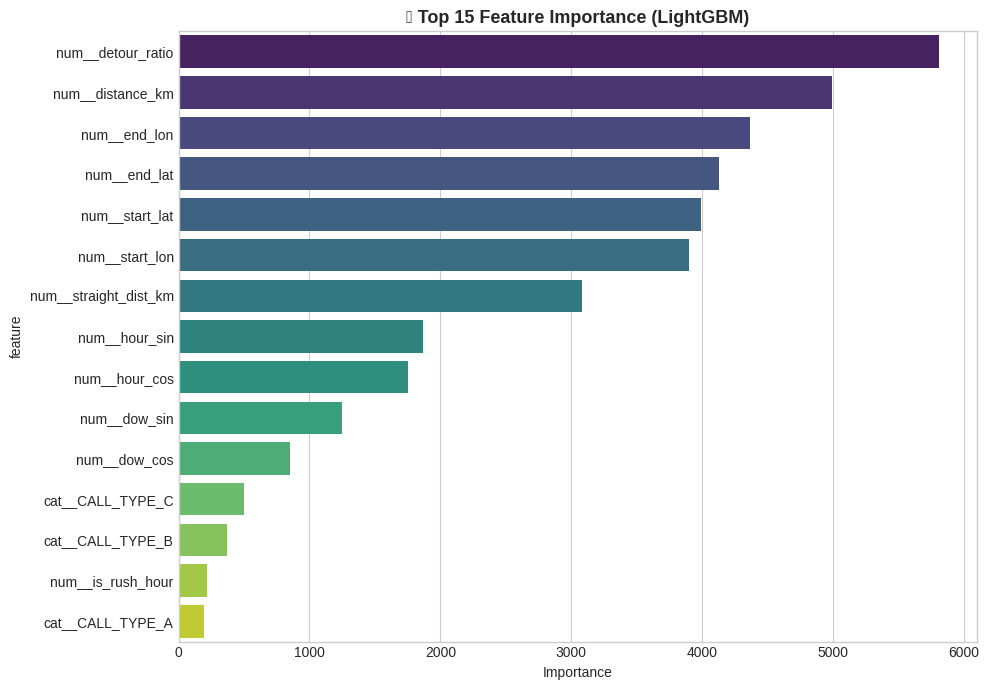

In [19]:
lgb_model = best_pipeline.named_steps['model']
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, y='feature', x='importance', palette='viridis')
plt.title('🏆 Top 15 Feature Importance (LightGBM)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 1️⃣5️⃣ Residual Plot

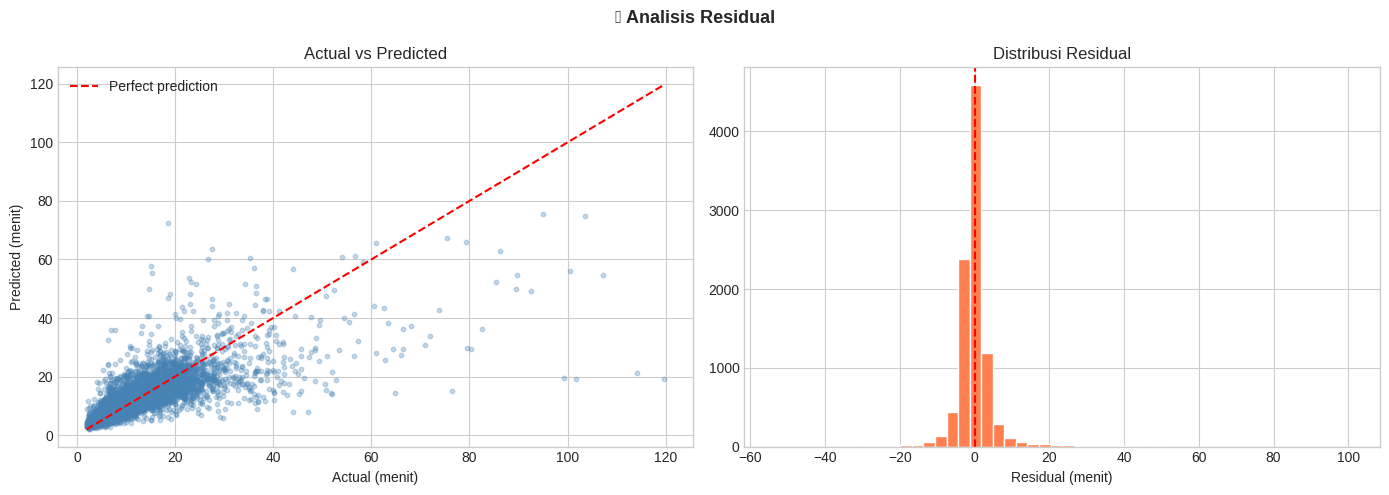

In [20]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🔍 Analisis Residual', fontsize=13, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.3, color='steelblue', s=10)
mn, mx = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual (menit)')
axes[0].set_ylabel('Predicted (menit)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residual distribution
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (menit)')
axes[1].set_title('Distribusi Residual')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/data/residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 1️⃣6️⃣ Simpan Model (.pkl) — Checklist #13

In [21]:
# Simpan full pipeline (preprocessor + model)
MODEL_PATH = f'{BASE_PATH}/models/eta_model_best.pkl'
FEATURE_PATH = f'{BASE_PATH}/models/feature_info.json'

joblib.dump(best_pipeline, MODEL_PATH)

# Simpan info fitur untuk API
feature_info = {
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'all_features': ALL_FEATURES,
    'target': TARGET,
    'best_params': best_params,
    'test_mae': float(final_result['MAE']),
    'test_rmse': float(final_result['RMSE']),
    'test_r2': float(final_result['R2'])
}
with open(FEATURE_PATH, 'w') as f:
    json.dump(feature_info, f, indent=2)

print(f'✅ Model disimpan  : {MODEL_PATH}')
print(f'✅ Feature info    : {FEATURE_PATH}')

✅ Model disimpan  : /content/drive/MyDrive/ml-eta/models/eta_model_best.pkl
✅ Feature info    : /content/drive/MyDrive/ml-eta/models/feature_info.json


## 1️⃣7️⃣ MLflow Logging — Checklist #8

In [22]:
mlflow.set_experiment('eta-prediction-bus-sekolah')

with mlflow.start_run(run_name='lgbm_tuned_optuna'):
    # Log params
    mlflow.log_params(best_params)
    # Log metrics
    mlflow.log_metric('test_mae',  final_result['MAE'])
    mlflow.log_metric('test_rmse', final_result['RMSE'])
    mlflow.log_metric('test_r2',   final_result['R2'])
    mlflow.log_metric('cv_mae_mean',  cv_mae.mean())
    mlflow.log_metric('cv_mae_std',   cv_mae.std())
    # Log model
    mlflow.sklearn.log_model(best_pipeline, 'eta_model')
    # Log artifacts
    mlflow.log_artifact(f'{BASE_PATH}/data/model_comparison.png')
    mlflow.log_artifact(f'{BASE_PATH}/data/feature_importance.png')
    mlflow.log_artifact(f'{BASE_PATH}/data/residual_plot.png')
    mlflow.log_artifact(f'{BASE_PATH}/models/feature_info.json')

print('✅ MLflow logging selesai!')
print('   Jalankan: mlflow ui  →  http://localhost:5000')

2026/05/05 07:49:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/05 07:49:59 INFO mlflow.store.db.utils: Updating database tables
2026/05/05 07:50:02 INFO mlflow.tracking.fluent: Experiment with name 'eta-prediction-bus-sekolah' does not exist. Creating a new experiment.
2026/05/05 07:50:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 07:50:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ MLflow logging selesai!
   Jalankan: mlflow ui  →  http://localhost:5000


## 1️⃣8️⃣ Inference Sederhana — Checklist #14

In [23]:
import joblib
import numpy as np

# Load model
loaded_model = joblib.load(f'{BASE_PATH}/models/eta_model_best.pkl')

# Contoh input: perjalanan dari titik A ke titik B
sample_input = pd.DataFrame([{
    'start_lat':         41.149,
    'start_lon':         -8.610,
    'end_lat':            41.157,
    'end_lon':            -8.650,
    'straight_dist_km':  4.2,
    'distance_km':       5.1,
    'detour_ratio':      1.21,
    'hour_sin':          np.sin(2 * np.pi * 7 / 24),   # jam 07:00
    'hour_cos':          np.cos(2 * np.pi * 7 / 24),
    'dow_sin':           np.sin(2 * np.pi * 0 / 7),    # Senin
    'dow_cos':           np.cos(2 * np.pi * 0 / 7),
    'is_weekend':        0,
    'is_rush_hour':      1,
    'month':             9,
    'time_category':     'pagi_sekolah',
    'CALL_TYPE':         'C'
}])

eta_minutes = loaded_model.predict(sample_input)[0]
eta_seconds = eta_minutes * 60

print('🚌 Hasil Prediksi ETA')
print(f'   Estimasi waktu tempuh : {eta_minutes:.1f} menit ({eta_seconds:.0f} detik)')
print(f'   Jam berangkat         : 07:00')

from datetime import datetime, timedelta
waktu_berangkat = datetime.strptime('07:00', '%H:%M')
waktu_tiba = waktu_berangkat + timedelta(minutes=eta_minutes)
print(f'   Estimasi tiba         : {waktu_tiba.strftime("%H:%M")}')

🚌 Hasil Prediksi ETA
   Estimasi waktu tempuh : 14.2 menit (853 detik)
   Jam berangkat         : 07:00
   Estimasi tiba         : 07:14
